In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re 
import os
import sys
import altair as alt

In [2]:
### labeling and binning evaluation of a batch of samples contained in a "data" directory
### the script will generate a "results" directory containing the results of the evaluation

In [3]:
base_dir = "/home/sgro"
input_dir = "/dataset"
cut_100_results = "/pbf-star-out-100"
cut_0_results = "/pbf-star-out"
output_dir = "/results"
test_name = 'B'
cuts = [0,100]

if test_name == 'B':
    pangenome_eval = "/home/sgro/blast-0"
    pangenome_eval_100 = "/home/sgro/blast-100"
    asm_eval = "/home/sgro/blast-asm"

if test_name == 'C':
    pangenome_eval = "/home/sgro/out-mod-C"
    pangenome_eval_100 = "/home/sgro/out-mod-C-100"
    asm_eval = "/home/sgro/blast-asm"


pbf_graphs = ['u','s', 'psm.u', 'psm.s']

eval_string = {}
for x in cuts:
    for y in pbf_graphs:
        eval_string.update({f"{str(x) + '.pbf.' + y}": []})
print(eval_string)
eval_string.update({"100.pbf.u": None})
eval_string.update({"100.pbf.s": None})


stat_map = {"prec": [], "rec": [], "f1": []}
stat_tests = {}
for test in eval_string.keys():
    stat_tests.update({test: stat_map})
print(stat_tests)

dataset = set()
# iterate over files in input_dir and create a sample list
for filename in os.listdir(base_dir + input_dir):
    if filename.endswith(".gz"):
        dataset.update({filename[0:-9]: {}})
print(dataset)
print(len(dataset), " number of samples, of which")
# divide samples by their type, i.e. their first 4 characters
sample_types = set()
for sample in dataset:
    sample_types.update({sample[0:4]})
print(sample_types)
# count the samples for each type
sample_count = {}
for sample_type in sample_types:
    sample_count.update({sample_type: 0})
for sample in dataset:
    sample_count[sample[0:4]] += 1
print(sample_count)

# filter dataset into dataste_supported including only the samples with the supported types that are eclo efae ecol abau kpne
dataset_supported = set()
supported_types = ["efae", "ecol", "abau", "kpne"]
for sample in dataset:
    if sample[0:4] in supported_types:
        dataset_supported.update({sample: {}})
print(dataset_supported)
print(len(dataset_supported), " number of supported samples, of which")
# divide supported samples by their type, i.e. their first 4 characters
sample_types_supported = set()
for sample in dataset_supported:
    sample_types_supported.update({sample[0:4]})
# print(sample_types_supported)
# count the supported samples for each type
sample_count_supported = {}
for sample_type in sample_types_supported:
    sample_count_supported.update({sample_type: 0})
for sample in dataset_supported:
    sample_count_supported[sample[0:4]] += 1
print(sample_count_supported)
# extract the list of supported samples
supported_samples = list(dataset_supported)
# remove the species name from the sample name
for i in range(len(supported_samples)):
    supported_samples[i] = supported_samples[i][5:]
print(supported_samples)



{'0.pbf.u': [], '0.pbf.s': [], '0.pbf.psm.u': [], '0.pbf.psm.s': [], '100.pbf.u': [], '100.pbf.s': [], '100.pbf.psm.u': [], '100.pbf.psm.s': []}
{'0.pbf.u': {'prec': [], 'rec': [], 'f1': []}, '0.pbf.s': {'prec': [], 'rec': [], 'f1': []}, '0.pbf.psm.u': {'prec': [], 'rec': [], 'f1': []}, '0.pbf.psm.s': {'prec': [], 'rec': [], 'f1': []}, '100.pbf.u': {'prec': [], 'rec': [], 'f1': []}, '100.pbf.s': {'prec': [], 'rec': [], 'f1': []}, '100.pbf.psm.u': {'prec': [], 'rec': [], 'f1': []}, '100.pbf.psm.s': {'prec': [], 'rec': [], 'f1': []}}
{'ecol-SAMN04014860', 'kpne-SAMN16357245', 'ehor-SAMN02713646', 'saur-SAMN03996304', 'paer-SAMN10346774', 'ecol-SAMN04014856', 'saur-SAMN03255446', 'kpne-SAMN16357452', 'ecol-SAMN04014847', 'saur-SAMN03255479', 'ecol-SAMD00056131', 'abau-SAMN16357502', 'kpne-SAMN11056344', 'saur-SAMN03255482', 'kpne-SAMN16357464', 'kpne-SAMEA3357272', 'saur-SAMN03255469', 'efae-SAMN03339922', 'saur-SAMN10163180', 'ecan-SAMN16357570', 'kpne-SAMEA3357077', 'paer-SAMN11056482',

In [4]:
plasgraph_dataset = "/home/sgro/dataset"

preprocessed = "/home/sgro/plas-out"
preprocessed_100 = "/home/sgro/plas-out-100"

results_pangenome = "/home/sgro/pbf-star-out"
results_pangenome_100 = "/home/sgro/pbf-star-out-100"
results_assemblies = "/home/sgro/pbf-assemblies-out/"


In [5]:
# divide files inside pangenome_eval into .plaseval.txt and stats.txt
plaseval_files = set()
stats_files = set()
for filename in os.listdir(pangenome_eval):
    if filename.endswith(".plaseval.txt"):
        plaseval_files.update({filename})
    elif filename.endswith("stats.txt"):
        stats_files.update({filename})

In [6]:
# divide files inside pangenome_eval_100 into .plaseval.txt and stats.txt
plaseval_files_100 = set()
stats_files_100 = set()
for filename in os.listdir(pangenome_eval_100):
    if filename.endswith(".plaseval.txt"):
        plaseval_files_100.update({filename})
    elif filename.endswith("stats.txt"):
        stats_files_100.update({filename})


In [7]:
# divide files inside asm_eval into .plaseval.txt and stats.txt
asm_files = set()
asm_stats_files = set()
for filename in os.listdir(asm_eval):
    if filename.endswith(".plaseval.txt"):
        asm_files.update({filename})
    elif filename.endswith("stats.txt"):
        asm_stats_files.update({filename})
        

In [8]:
# filter the supported samples in asm_files, pangenome_eval and pangenome_eval_100
plaseval_files_supported = set()
for sample in supported_samples:
    for filename in plaseval_files:
        if sample in filename:
            plaseval_files_supported.update({filename})
plaseval_files_100_supported = set()
for sample in supported_samples:
    for filename in plaseval_files_100:
        if sample in filename:
            plaseval_files_100_supported.update({filename})
            
asm_files_supported = set()
for sample in supported_samples:
    for filename in asm_files:
        if sample in filename:
            asm_files_supported.update({filename})
    

In [9]:
# # filter the supported samples in asm_stats_files, stats_files and stats_files_100
stats_files_supported = set()
for sample in supported_samples:
    for filename in stats_files:
        if sample in filename:
            stats_files_supported.update({filename})
stats_files_100_supported = set()
for sample in supported_samples:
    for filename in stats_files_100:
        if sample in filename:
            stats_files_100_supported.update({filename})
asm_stats_files_supported = set()
for sample in supported_samples:
    for filename in asm_stats_files:
        if sample in filename:
            asm_stats_files_supported.update({filename})



In [10]:
# extract id from asm_files_supported
asm_ids = set()
for filename in asm_files_supported:
    asm_ids.update({filename[0:12]})
# print(asm_ids)
# extract id from plaseval_files_supported
plaseval_ids = set()
for filename in plaseval_files_supported:
    plaseval_ids.update({filename[0:12]})
# print(plaseval_ids)
# extract id from plaseval_files_100_supported
plaseval_ids_100 = set()
for filename in plaseval_files_100_supported:
    plaseval_ids_100.update({filename[0:12]})
# print(plaseval_ids_100)

# extract the list of common ids between asm_ids and plaseval_ids  and plaseval_ids_100
common_ids = set()
for id in asm_ids:
    if id in plaseval_ids and id in plaseval_ids_100:
        common_ids.update({id})
print(common_ids)
print(len(common_ids), " number of common ids")

{'SAMN16357467', 'SAMN11056346', 'SAMN07312483', 'SAMEA3357268', 'SAMN03024573', 'SAMN16357458', 'SAMN16357457', 'SAMN16357468', 'SAMN16357460', 'SAMN16357455', 'SAMN10163190', 'SAMN11056344', 'SAMN16357454', 'SAMN11056345', 'SAMEA3357010', 'SAMN16357449', 'SAMN16357450', 'SAMN04014860', 'SAMN04014852', 'SAMN02991226', 'SAMN16357459', 'SAMN16357501', 'SAMN16357245', 'SAMN10163228', 'SAMEA3357077', 'SAMN16357456', 'SAMEA3357272', 'SAMN03996301', 'SAMEA3357043', 'SAMN16357464', 'SAMN03024583', 'SAMN16357452', 'SAMN16357451', 'SAMD00056131', 'SAMN07312490', 'SAMN16357205', 'SAMN04014856', 'SAMN16357465', 'SAMN16357470', 'SAMN16357448', 'SAMN07312488', 'SAMN04014847', 'SAMN16357453', 'SAMN16357462', 'SAMN16357471', 'SAMN02786856'}
46  number of common ids


In [11]:
# from the common ids extract the list of files in asm_files_supported, plaseval_files_supported and plaseval_files_100_supported
asm_files_common = set()
plaseval_files_common = set()
plaseval_files_100_common = set()
for id in common_ids:
    for filename in asm_files_supported:
        if id in filename:
            asm_files_common.update({filename})
    for filename in plaseval_files_supported:
        if id in filename:
            plaseval_files_common.update({filename})
    for filename in plaseval_files_100_supported:
        if id in filename:
            plaseval_files_100_common.update({filename})
print(len(asm_files_common))
print(len(plaseval_files_common))
print(len(plaseval_files_100_common))
print(asm_files_common)

# from the common ids extract the list of files in asm_stats_files_supported, stats_files_supported and stats_files_100_supported
asm_stats_files_common = set()
stats_files_common = set()
stats_files_100_common = set()
for id in common_ids:
    for filename in asm_stats_files_supported:
        if id in filename:
            asm_stats_files_common.update({filename})
    for filename in stats_files_supported:
        if id in filename:
            stats_files_common.update({filename})
    for filename in stats_files_100_supported:
        if id in filename:
            stats_files_100_common.update({filename})
print(len(asm_stats_files_common))
print(len(stats_files_common))
print(len(stats_files_100_common))
print(asm_stats_files_common)


89
92
92
{'SAMN16357468.pbf.uni.plaseval.txt', 'SAMN16357468.pbf.ske.plaseval.txt', 'SAMN16357448.pbf.uni.plaseval.txt', 'SAMN16357453.pbf.ske.plaseval.txt', 'SAMN02991226.pbf.uni.plaseval.txt', 'SAMN16357470.pbf.ske.plaseval.txt', 'SAMN02786856.pbf.uni.plaseval.txt', 'SAMN10163228.pbf.uni.plaseval.txt', 'SAMN04014860.pbf.uni.plaseval.txt', 'SAMN16357459.pbf.ske.plaseval.txt', 'SAMN16357470.pbf.uni.plaseval.txt', 'SAMN04014856.pbf.uni.plaseval.txt', 'SAMEA3357043.pbf.uni.plaseval.txt', 'SAMEA3357272.pbf.ske.plaseval.txt', 'SAMN16357454.pbf.uni.plaseval.txt', 'SAMEA3357268.pbf.ske.plaseval.txt', 'SAMN16357454.pbf.ske.plaseval.txt', 'SAMN11056346.pbf.ske.plaseval.txt', 'SAMN16357245.pbf.uni.plaseval.txt', 'SAMN16357205.pbf.ske.plaseval.txt', 'SAMN16357465.pbf.uni.plaseval.txt', 'SAMN16357458.pbf.uni.plaseval.txt', 'SAMN16357452.pbf.uni.plaseval.txt', 'SAMEA3357272.pbf.uni.plaseval.txt', 'SAMN16357451.pbf.ske.plaseval.txt', 'SAMD00056131.pbf.uni.plaseval.txt', 'SAMN10163190.pbf.uni.plasev

In [12]:
# divide files in asm_files_common into 2 groups, one containing the files with the string ".u." and the other with the string ".s."
asm_files_common_u = set()
asm_files_common_s = set()
for filename in asm_files_common:
    if ".uni." in filename:
        asm_files_common_u.update({filename})
    elif ".ske." in filename:
        asm_files_common_s.update({filename})
print(len(asm_files_common_u))
print(len(asm_files_common_s))

# divide files in plaseval_files_common into 2 groups, one containing the files with the string ".u." and the other with the string ".s."
plaseval_files_common_u = set()
plaseval_files_common_s = set()
for filename in plaseval_files_common:
    if ".u." in filename:
        plaseval_files_common_u.update({filename})
    elif ".s." in filename:
        plaseval_files_common_s.update({filename})
print(len(plaseval_files_common_u))
print(len(plaseval_files_common_s))

# divide files in plaseval_files_100_common into 2 groups, one containing the files with the string ".u." and the other with the string ".s."
plaseval_files_common_100_u = set()
plaseval_files_common_100_s = set()

for filename in plaseval_files_100_common:
    if ".u." in filename:
        plaseval_files_common_100_u.update({filename})
    elif ".s." in filename:
        plaseval_files_common_100_s.update({filename})
print(len(plaseval_files_common_100_u))
print(len(plaseval_files_common_100_s))


45
44
46
46
46
46


In [13]:

eval_string_stats = {}
for x in cuts:
    for y in pbf_graphs:
        eval_string_stats.update({f"{str(x) + '.pbf.' + y}": []})

for filename in asm_stats_files_common:
    with open(asm_eval + "/" + filename, "r") as file:
        lines = file.readlines()
        prec, rec, f1 = float(lines[-4].split("\t")[-1].strip()), float(lines[-3].split("\t")[-1].strip()), float(lines[-2].split("\t")[-1].strip())
    # print(prec, rec, f1)
    if '.uni.' in filename:
        test = '0.pbf.u'
    elif '.ske.' in filename:
        test = '0.pbf.s'
    id = filename[0:12]
    eval_string_stats[test].append({id:[prec, rec, f1]})
    # print(eval_string)

for filename in stats_files_common:
    with open(pangenome_eval + "/" + filename, "r") as file:
        lines = file.readlines()
        prec, rec, f1 = float(lines[-4].split("\t")[-1].strip()), float(lines[-3].split("\t")[-1].strip()), float(lines[-2].split("\t")[-1].strip())
    # print(prec, rec, f1)
    if '.u.' in filename:
        test = '0.pbf.psm.u'
    elif '.s.' in filename:
        test = '0.pbf.psm.s'
    id = filename[0:12]
    eval_string_stats[test].append({id:[prec, rec, f1]})
    # print(eval_string)
    
for filename in stats_files_100_common:
    with open(pangenome_eval_100 + "/" + filename, "r") as file:
        lines = file.readlines()
        prec, rec, f1 = float(lines[-4].split("\t")[-1].strip()), float(lines[-3].split("\t")[-1].strip()), float(lines[-2].split("\t")[-1].strip())
    # print(prec, rec, f1)
    if '.u.' in filename:
        test = '100.pbf.psm.u'
    elif '.s.' in filename:
        test = '100.pbf.psm.s'
    id = filename[0:12]
    eval_string_stats[test].append({id:[prec, rec, f1]})
    # print(eval_string)


for filename in asm_files_common:
    with open(asm_eval + "/" + filename, "r") as file:
        lines = file.readlines()
        prec, rec, f1 = float(lines[-3].split("\t")[-1].strip()), float(lines[-2].split("\t")[-1].strip()), float(lines[-1].split("\t")[-1].strip())
    # print(prec, rec, f1)
    if '.uni.' in filename:
        test = '0.pbf.u'
    elif '.ske.' in filename:
        test = '0.pbf.s'
    id = filename[0:12]
    eval_string[test].append({id:[prec, rec, f1]})
    # print(eval_string)

for filename in plaseval_files_common:
    with open(pangenome_eval + "/" + filename, "r") as file:
        lines = file.readlines()
        prec, rec, f1 = float(lines[-3].split("\t")[-1].strip()), float(lines[-2].split("\t")[-1].strip()), float(lines[-1].split("\t")[-1].strip())
    # print(prec, rec, f1)
    if '.u.' in filename:
        test = '0.pbf.psm.u'
    elif '.s.' in filename:
        test = '0.pbf.psm.s'
    id = filename[0:12]
    eval_string[test].append({id:[prec, rec, f1]})
    # print(eval_string)

for filename in plaseval_files_100_common:
    with open(pangenome_eval_100 + "/" + filename, "r") as file:
        lines = file.readlines()
        prec, rec, f1 = float(lines[-3].split("\t")[-1].strip()), float(lines[-2].split("\t")[-1].strip()), float(lines[-1].split("\t")[-1].strip())
    if '.u.' in filename:
        test = '100.pbf.psm.u'
    elif '.s.' in filename:
        test = '100.pbf.psm.s'
    # print(prec, rec, f1)
    id = filename[0:12]
    eval_string[test].append({id:[prec, rec, f1]})


mean_eval_string = {}
for sample in common_ids:
    sample_key = sample[:12]
    psm_s_values = [entry[sample_key] for entry in eval_string['0.pbf.psm.s'] if sample_key in entry]
    psm_u_values = [entry[sample_key] for entry in eval_string['0.pbf.psm.u'] if sample_key in entry]
    
    if psm_s_values and psm_u_values:
        mean_prec = float(np.mean([psm_s_values[0][0], psm_u_values[0][0]]))
        mean_rec = float(np.mean([psm_s_values[0][1], psm_u_values[0][1]]))
        mean_f1 = float(np.mean([psm_s_values[0][2], psm_u_values[0][2]]))
        mean_eval_string[sample_key] = [mean_prec, mean_rec, mean_f1]



mean_eval_string_100 = {}
for sample in common_ids:
    sample_key = sample[:12]
    psm_s_values = [entry[sample_key] for entry in eval_string['100.pbf.psm.s'] if sample_key in entry]
    psm_u_values = [entry[sample_key] for entry in eval_string['100.pbf.psm.u'] if sample_key in entry]
    
    if psm_s_values and psm_u_values:
        mean_prec = float(np.mean([psm_s_values[0][0], psm_u_values[0][0]]))
        mean_rec = float(np.mean([psm_s_values[0][1], psm_u_values[0][1]]))
        mean_f1 = float(np.mean([psm_s_values[0][2], psm_u_values[0][2]]))
        mean_eval_string_100[sample_key] = [mean_prec, mean_rec, mean_f1]


# for each sample compute mean(['0.pbf.psm.s'],['0.pbf.psm.u']) for eval_string_stats
mean_eval_string_stats = {}
for sample in common_ids:
    sample_key = sample[:12]
    psm_s_values = [entry[sample_key] for entry in eval_string_stats['0.pbf.psm.s'] if sample_key in entry]
    psm_u_values = [entry[sample_key] for entry in eval_string_stats['0.pbf.psm.u'] if sample_key in entry]
    
    if psm_s_values and psm_u_values:
        mean_prec = float(np.mean([psm_s_values[0][0], psm_u_values[0][0]]))
        mean_rec = float(np.mean([psm_s_values[0][1], psm_u_values[0][1]]))
        mean_f1 = float(np.mean([psm_s_values[0][2], psm_u_values[0][2]]))
        mean_eval_string_stats[sample_key] = [mean_prec, mean_rec, mean_f1]



mean_eval_string_stats_100 = {}
for sample in common_ids:
    sample_key = sample[:12]
    psm_s_values = [entry[sample_key] for entry in eval_string_stats['100.pbf.psm.s'] if sample_key in entry]
    psm_u_values = [entry[sample_key] for entry in eval_string_stats['100.pbf.psm.u'] if sample_key in entry]
    
    if psm_s_values and psm_u_values:
        mean_prec = float(np.mean([psm_s_values[0][0], psm_u_values[0][0]]))
        mean_rec = float(np.mean([psm_s_values[0][1], psm_u_values[0][1]]))
        mean_f1 = float(np.mean([psm_s_values[0][2], psm_u_values[0][2]]))
        mean_eval_string_stats_100[sample_key] = [mean_prec, mean_rec, mean_f1]


In [14]:
header = ["sample", "tool", "precision", "recall", "f1"]
df_stats_a = pd.DataFrame(columns = header)
for x in mean_eval_string.keys():
    try:
        df_stats_a = pd.concat([df_stats_a, pd.DataFrame([[x, "0.pbf.psm", mean_eval_string_stats[x][0], mean_eval_string_stats[x][1], mean_eval_string_stats[x][2]]], columns = header)], ignore_index = True)
        df_stats_a = pd.concat([df_stats_a, pd.DataFrame([[x, "100.pbf.psm", mean_eval_string_stats_100[x][0], mean_eval_string_stats_100[x][1], mean_eval_string_stats_100[x][2]]], columns = header)], ignore_index = True)
    except:
        pass

In [15]:
# filter out from df_stats if tool != [0.pbf.u, 0.pbf.s, 0.pbf.psm.u, 0.pbf.psm.s]
df_stats = pd.read_csv("./results.csv", sep="\t", header=0, names=header, index_col=0)

df_stats = df_stats[df_stats['tool'].isin(['0.pbf.uni', '0.pbf.ske'])]
df_stats = df_stats[df_stats['sample'].isin(common_ids)]

# rename the tools in df_stats
df_stats['tool'] = df_stats['tool'].replace({'0.pbf.uni': '0.pbf.u', '0.pbf.ske': '0.pbf.s', '0.pbf.panstar.uni': '0.pbf.psm.u', '0.pbf.panstar.uni': '0.pbf.psm.s', '100.pbf.panstar.uni': '100.pbf.psm.u', '100.pbf.panstar.uni': '100.pbf.psm.s'})

# filter out from df_stats_a if tool != [0.pbf.u, 0.pbf.s, 0.pbf.psm.u, 0.pbf.psm.s]
df_stats_a = df_stats_a[df_stats_a['tool'].isin(['0.pbf.psm', '100.pbf.psm'])]
# merge df_stats and df_stats_a

df_stats = pd.concat([df_stats, df_stats_a], ignore_index=True)


/tmp/ipykernel_473944/4292616030.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_stats = pd.concat([df_stats, df_stats_a], ignore_index=True)


In [16]:

# pangenome_eval = "/home/sgro/out-mod-C"
# pangenome_eval_100 = "/home/sgro/out-mod-C-100"
# asm_eval = "/home/sgro/blast-asm"

In [17]:
header = ["sample", "tool", "precision", "recall", "f1"]
df = pd.DataFrame(columns=header)

for test in eval_string.keys()-{"100.pbf.psm.u", "100.pbf.psm.s", "0.pbf.psm.u", "0.pbf.psm.s", "100.pbf.u", "100.pbf.s"}:
    for id in eval_string[test]:
        for key, value in id.items():
            df = pd.concat([df, pd.DataFrame({"sample": key, "tool": test, "precision": value[0], "recall": value[1], "f1": value[2]}, index=[0])], ignore_index=True)

for x in mean_eval_string.keys():
    df = pd.concat([df, pd.DataFrame([[x, "0.pbf.psm", mean_eval_string[x][0], mean_eval_string[x][1], mean_eval_string[x][2]]], columns = header)], ignore_index = True)
    df = pd.concat([df, pd.DataFrame([[x, "100.pbf.psm", mean_eval_string_100[x][0], mean_eval_string_100[x][1], mean_eval_string_100[x][2]]], columns = header)], ignore_index = True)
    

/tmp/ipykernel_473944/1540396900.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame({"sample": key, "tool": test, "precision": value[0], "recall": value[1], "f1": value[2]}, index=[0])], ignore_index=True)


In [18]:
# remove for df entries if a samples has precision and recall equal to 0 for each tool
# df = df[(df['precision'] > 0.2) & (df['recall'] > 0.2)]
# df_stats = df_stats[(df_stats['precision'] > 0.1) & (df_stats['recall'] > 0.1)]

nsamples = len(df['sample'].unique())
print (nsamples)
print (len(df_stats['sample'].unique()))


46
40


/tmp/ipykernel_473944/2676157400.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="tool", y="precision", data=df, palette=colors, ax=axs[0])
/tmp/ipykernel_473944/2676157400.py:25: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.boxplot(x="tool", y="precision", data=df, palette=colors, ax=axs[0])
/tmp/ipykernel_473944/2676157400.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="tool", y="recall", data=df, palette=colors, ax=axs[1])
/tmp/ipykernel_473944/2676157400.py:30: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.boxplot(x="tool", y="recall", data=df, palette=colors, ax=

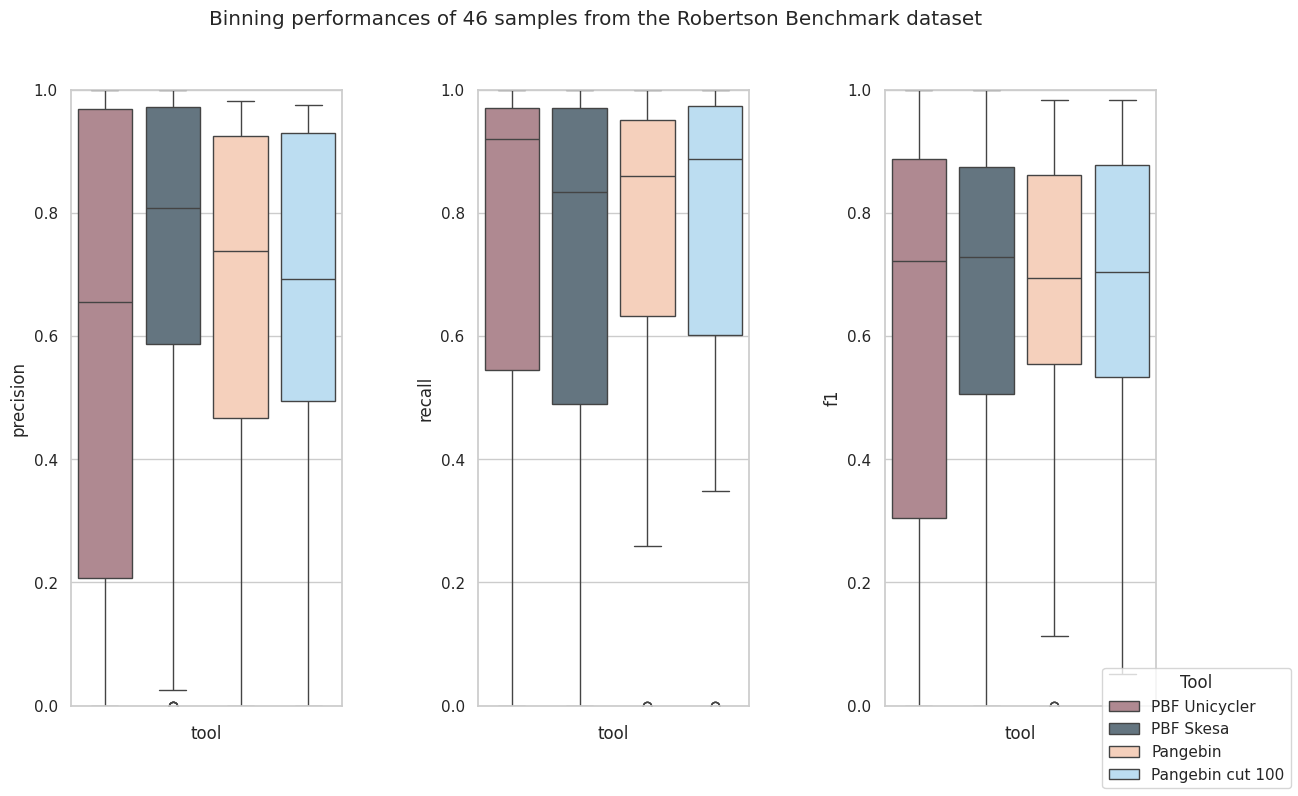

In [19]:

sns.set_theme(style="whitegrid")
# color .s and .u in different colors
colors = ['#b5838d', '#5F7685', 
    '#ffcdb2', '#B3DFFA',
          '#ffb4a2', '#9ABFD6',
          '#e5989b', '#7D9BAD']

colors2 = ['#5F7685', '#b5838d',
            '#B3DFFA', '#ffcdb2',
            '#9ABFD6', '#ffb4a2',
            '#7D9BAD', '#e5989b']

          
sns.set_palette(sns.color_palette(colors))

fig, axs = plt.subplots(1, 3, figsize=(14, 8))
fig.suptitle(f"Binning performances of {nsamples} samples from the Robertson Benchmark dataset")

plt.xticks(rotation=90)
axs[0].set_ylim(0, 1)
axs[1].set_ylim(0, 1)
axs[2].set_ylim(0, 1)

plt.subplots_adjust(wspace=0.5)
sns.boxplot(x="tool", y="precision", data=df, palette=colors, ax=axs[0])
axs[0].set_xticklabels([])
axs[1].set_xticklabels([])
axs[2].set_xticklabels([])

sns.boxplot(x="tool", y="recall", data=df, palette=colors, ax=axs[1])
sns.boxplot(x="tool", y="f1", data=df, palette=colors, ax=axs[2])
fig.legend(title="Tool", labels=["PBF Unicycler", "PBF Skesa", "Pangebin", "Pangebin cut 100"], loc="lower right")
plt.savefig(f"boxplot-binning-{test_name}.png")
plt.show()

/tmp/ipykernel_473944/2965540509.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="tool", y="precision", data=df_stats, palette=colors, ax=axs[0])
/tmp/ipykernel_473944/2965540509.py:26: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.boxplot(x="tool", y="precision", data=df_stats, palette=colors, ax=axs[0])
/tmp/ipykernel_473944/2965540509.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="tool", y="recall", data=df_stats, palette=colors, ax=axs[1])
/tmp/ipykernel_473944/2965540509.py:37: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.boxplot(x="tool", y="recall", data=df_st

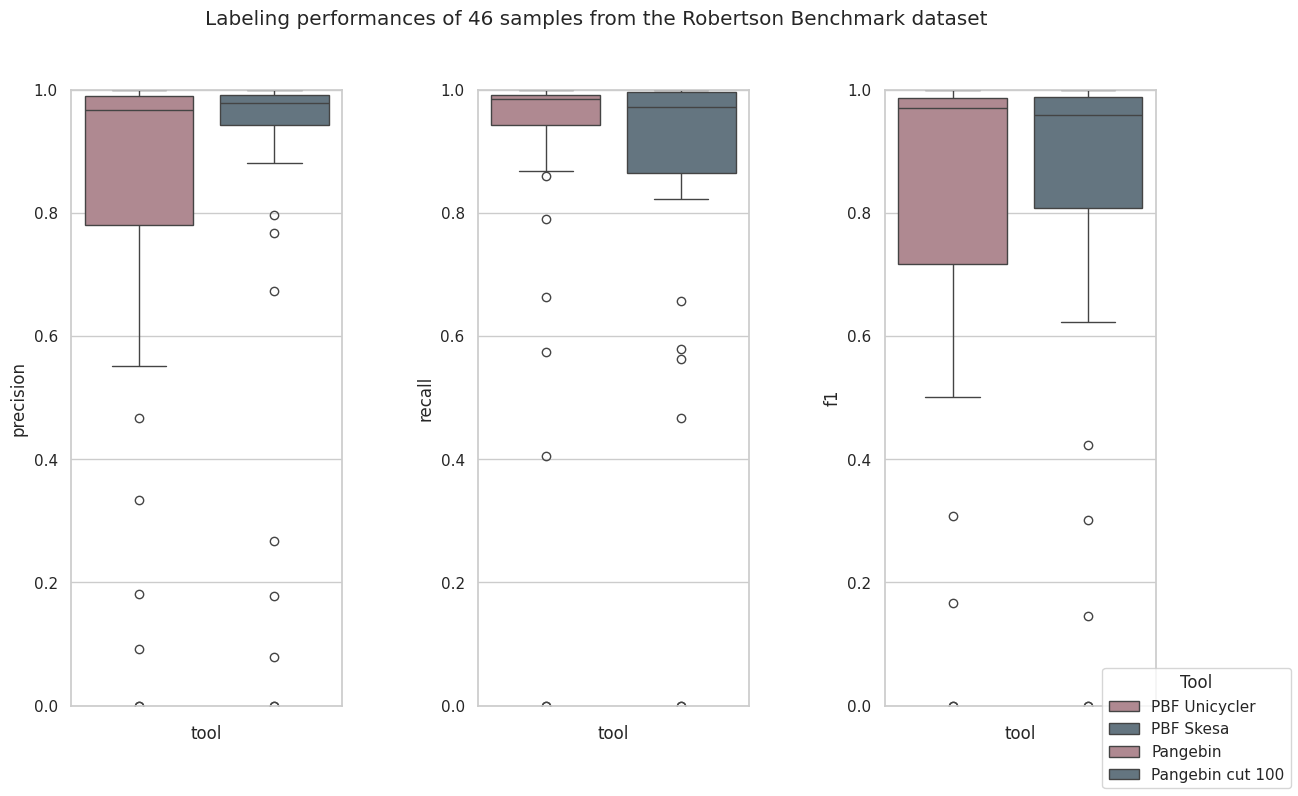

In [20]:

# box plot of the stats files
sns.set_theme(style="whitegrid")
# color .s and .u in different colors
colors = ["#9b59b6", "#3498db", "#95a5a6", "#e74c3c", "#34495e", "#2ecc71"]
colors = ['#b5838d', '#5F7685', 
    '#ffcdb2', '#B3DFFA',
          '#ffb4a2', '#9ABFD6',
          '#e5989b', '#7D9BAD']

sns.set_palette(sns.color_palette(colors))


# put the 3 plots in the same figure
fig, axs = plt.subplots(1, 3, figsize=(14, 8))
# give a title to the fig
fig.suptitle(f"Labeling performances of {nsamples} samples from the Robertson Benchmark dataset")
# insert legend
# legend title
# rotate the labels of the x axis
plt.xticks(rotation=90)
axs[0].set_ylim(0, 1)
axs[1].set_ylim(0, 1)
axs[2].set_ylim(0, 1)

plt.subplots_adjust(wspace=0.5)
sns.boxplot(x="tool", y="precision", data=df_stats, palette=colors, ax=axs[0])
# do not show x labels
axs[0].set_xticklabels([])
axs[1].set_xticklabels([])
axs[2].set_xticklabels([])
# vertical name of columns

# axs[1].set_xticklabels(axs[0].get_xticklabels(), rotation=90)
# axs[2].set_xticklabels(axs[0].get_xticklabels(), rotation=90)
# vertical name of columns

sns.boxplot(x="tool", y="recall", data=df_stats, palette=colors, ax=axs[1])

sns.boxplot(x="tool", y="f1", data=df_stats, palette=colors, ax=axs[2])
fig.legend(title="Tool", labels=["PBF Unicycler", "PBF Skesa", "Pangebin", "Pangebin cut 100"], loc="lower right")

plt.savefig(f"boxplot-precision-{test_name}.png")
plt.show()



In [21]:
# top scoring samples for 0.pbf.psm
top_samples = df_stats[df_stats['tool'] == '0.pbf.psm'].sort_values(by='f1', ascending=False).head(10)
print(top_samples)

Empty DataFrame
Columns: [sample, tool, precision, recall, f1]
Index: []


In [22]:
# top scoring samples for 100.pbf.psm
top_samples_100 = df_stats[df_stats['tool'] == '100.pbf.psm'].sort_values(by='f1', ascending=False).head(10)
print(top_samples_100)

Empty DataFrame
Columns: [sample, tool, precision, recall, f1]
Index: []


In [23]:
import gfapy as gf

gfa = gf.Gfa.from_file("/home/sgro/plas-out/kpne.SAMN16357452.0.panasm.gfa")


In [24]:
fragment_set = {}

for line in gfa.lines:
    if line.record_type == "P":
        fragment_set[line.name] = [str(x)[:-1] for x in line.segment_names]
print(fragment_set)

{'ske1': ['143'], 'ske2': ['364', '365'], 'ske3': ['50', '51', '52'], 'ske4': ['1'], 'ske5': ['289', '288', '287'], 'ske6': ['359'], 'ske7': ['327', '329'], 'ske8': ['158'], 'ske9': ['2', '3', '4'], 'ske10': ['370', '372'], 'ske11': ['382', '383'], 'ske12': ['360'], 'ske13': ['188'], 'ske14': ['32', '33'], 'ske15': ['149'], 'ske16': ['379'], 'ske17': ['91'], 'ske18': ['88'], 'ske19': ['172', '173', '174', '175', '176', '177', '178', '179'], 'ske20': ['5'], 'ske21': ['356', '357'], 'ske22': ['385', '384'], 'ske23': ['375'], 'ske24': ['196'], 'ske25': ['6'], 'ske26': ['374'], 'ske27': ['7'], 'ske28': ['127'], 'ske29': ['78'], 'ske30': ['8', '9'], 'ske31': ['362'], 'ske32': ['123'], 'ske33': ['116'], 'ske34': ['54'], 'ske35': ['141'], 'ske36': ['125'], 'ske37': ['134', '136'], 'ske38': ['390'], 'ske39': ['10', '11'], 'ske40': ['79'], 'ske41': ['366', '368'], 'ske42': ['12'], 'ske43': ['100'], 'ske44': ['13', '14'], 'ske45': ['388', '389'], 'ske46': ['104', '105', '106', '107', '108', '109